In [1]:
import pandas as pd
import pyarrow.parquet as pq

cleaned_reviews_path = "../../data/processed/steam_reviews_cleaned_english.parquet"

pf = pq.ParquetFile(cleaned_reviews_path)
n_groups = min(5, pf.metadata.num_row_groups)   # in case file has fewer than 10
table = pf.read_row_groups(range(n_groups))
df = table.to_pandas()
df.shape

(1044988, 19)

In [2]:
# don't limit the number of columns shown in pandas
pd.set_option('display.max_columns', None)


In [3]:
table

pyarrow.Table
review_id: int64
app_id: int64
app_name: large_string
author.steamid: int64
review: large_string
recommended: bool
votes_helpful: int64
author.num_games_owned: int64
author.num_reviews: int64
author.playtime_last_two_weeks: double
author.playtime_at_review: double
steam_purchase: bool
received_for_free: bool
written_during_early_access: bool
timestamp_created: int64
author.last_played: double
is_helpful: bool
review_length_chars: int64
review_word_count: int64
----
review_id: [[85184605,85184171,85184064,85180436,85179753,...,65157270,65156307,65151509,65143417,65135676]]
app_id: [[292030,292030,292030,292030,292030,...,477160,477160,477160,477160,477160]]
app_name: [["The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt",...,"Human: Fall Flat","Human: Fall Flat","Human: Fall Flat","Human: Fall Flat","Human: Fall Flat"]]
author.steamid: [[76561199054755373,76561198170193529,76561198119302812,7

In [4]:
df.shape

(1044988, 19)

In [5]:
df.head()

,review_id,app_id,app_name,author.steamid,review,recommended,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,author.playtime_at_review,steam_purchase,received_for_free,written_during_early_access,timestamp_created,author.last_played,is_helpful,review_length_chars,review_word_count
0,85184605,292030,The Witcher 3: Wild Hunt,76561199054755373,"One of the best RPG's of all time, worthy of a...",True,0,5,3,3200.0,5524.0,True,False,False,1611379970,1.611384e+09,False,59,12
1,85184171,292030,The Witcher 3: Wild Hunt,76561198170193529,"good story, good graphics. lots to do.",True,0,11,1,823.0,823.0,True,False,False,1611379264,1.611379e+09,False,38,7
2,85184064,292030,The Witcher 3: Wild Hunt,76561198119302812,"dis gud,",True,0,27,2,3398.0,4192.0,True,False,False,1611379091,1.611352e+09,False,8,2
3,85180436,292030,The Witcher 3: Wild Hunt,76561198065591528,favorite game of all time cant wait for the Ne...,True,0,33,1,177.0,23329.0,True,False,False,1611373086,1.611219e+09,False,59,11
4,85179753,292030,The Witcher 3: Wild Hunt,76561198996835044,Why wouldn't you get this,True,0,131,2,2004.0,8557.0,True,False,False,1611371978,1.611371e+09,False,25,5


In [6]:
import plotly.express as px

# Create a DataFrame with just the columns of interest and count the combinations
combo_counts = (
    df.groupby(["app_name", "recommended", "is_helpful"])
      .size()
      .reset_index(name="count")
)

# See how many unique combinations exist
num_combos = combo_counts.shape[0]
print(f"Number of unique (app_name, recommended, is_helpful) combinations: {num_combos}")

# Show histogram: how many times does each combination occur?
fig = px.histogram(
    combo_counts,
    x="count",
    nbins=50,
    title="Histogram of Combination Counts (app_name, recommended, is_helpful)",
    labels={"count": "Number of Occurrences"},
)
fig.show()

# Optionally: Display the most frequent combinations
display(combo_counts.sort_values("count", ascending=False).head(10))
display(combo_counts.sort_values("count", ascending=True).head(10))

Number of unique (app_name, recommended, is_helpful) combinations: 48


,app_name,recommended,is_helpful,count
10,Garry's Mod,True,False,228053
42,The Witcher 3: Wild Hunt,True,False,101149
26,Portal 2,True,False,81761
6,Dead by Daylight,True,False,80795
30,Sid Meier's Civilization V,True,False,75394
11,Garry's Mod,True,True,71996
38,Subnautica,True,False,65492
43,The Witcher 3: Wild Hunt,True,True,42167
34,Sid Meier's Civilization VI,True,False,42108
7,Dead by Daylight,True,True,30302


,app_name,recommended,is_helpful,count
21,Human: Fall Flat,False,True,84
16,Half-Life 2: Episode Two,False,False,128
20,Human: Fall Flat,False,False,258
46,X Rebirth,True,False,262
17,Half-Life 2: Episode Two,False,True,309
44,X Rebirth,False,False,364
24,Portal 2,False,False,369
12,Half-Life,False,False,439
13,Half-Life,False,True,562
1,Counter-Strike: Source,False,True,762


In [7]:
# Stratified sampling to split the data by ("app_name", "recommended", "is_helpful")
from sklearn.model_selection import train_test_split

# Add a column that combines the three stratification keys
df["stratify_group"] = df.apply(lambda row: f"{row['app_name']}|{row['recommended']}|{row['is_helpful']}", axis=1)

# Note: Some groups may be very small; consider filtering/merging rare groups for "real" splits

# First, split into train+val and test sets (stratified)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["stratify_group"]
)

# Now split train_val into train and validation sets (stratified)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,  # 0.25 x 0.8 = 0.2 of original data (so 60/20/20 split)
    random_state=42,
    stratify=train_val_df["stratify_group"]
)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

# Clean up temporary column if desired
df.drop(columns=["stratify_group"], inplace=True)
train_df = train_df.drop(columns=["stratify_group"])
val_df = val_df.drop(columns=["stratify_group"])
test_df = test_df.drop(columns=["stratify_group"])

Train shape: (626992, 20)
Validation shape: (208998, 20)
Test shape: (208998, 20)


In [8]:
# Confirm stratification is preserved in the sample splits
def show_group_counts(df, label):
    combo_counts = (
        df.groupby(["app_name", "recommended", "is_helpful"])
          .size()
          .reset_index(name="count")
    )
    print(f"\nTop groups in {label} set:")
    display(combo_counts.sort_values("count", ascending=False).head(10))

show_group_counts(train_df, "train")
show_group_counts(val_df, "validation")
show_group_counts(test_df, "test")


Top groups in train set:


,app_name,recommended,is_helpful,count
10,Garry's Mod,True,False,136831
42,The Witcher 3: Wild Hunt,True,False,60689
26,Portal 2,True,False,49057
6,Dead by Daylight,True,False,48477
30,Sid Meier's Civilization V,True,False,45236
11,Garry's Mod,True,True,43198
38,Subnautica,True,False,39295
43,The Witcher 3: Wild Hunt,True,True,25300
34,Sid Meier's Civilization VI,True,False,25264
7,Dead by Daylight,True,True,18181



Top groups in validation set:


,app_name,recommended,is_helpful,count
10,Garry's Mod,True,False,45611
42,The Witcher 3: Wild Hunt,True,False,20230
26,Portal 2,True,False,16352
6,Dead by Daylight,True,False,16159
30,Sid Meier's Civilization V,True,False,15079
11,Garry's Mod,True,True,14399
38,Subnautica,True,False,13098
43,The Witcher 3: Wild Hunt,True,True,8433
34,Sid Meier's Civilization VI,True,False,8422
7,Dead by Daylight,True,True,6061



Top groups in test set:


,app_name,recommended,is_helpful,count
10,Garry's Mod,True,False,45611
42,The Witcher 3: Wild Hunt,True,False,20230
26,Portal 2,True,False,16352
6,Dead by Daylight,True,False,16159
30,Sid Meier's Civilization V,True,False,15079
11,Garry's Mod,True,True,14399
38,Subnautica,True,False,13099
43,The Witcher 3: Wild Hunt,True,True,8434
34,Sid Meier's Civilization VI,True,False,8422
7,Dead by Daylight,True,True,6060


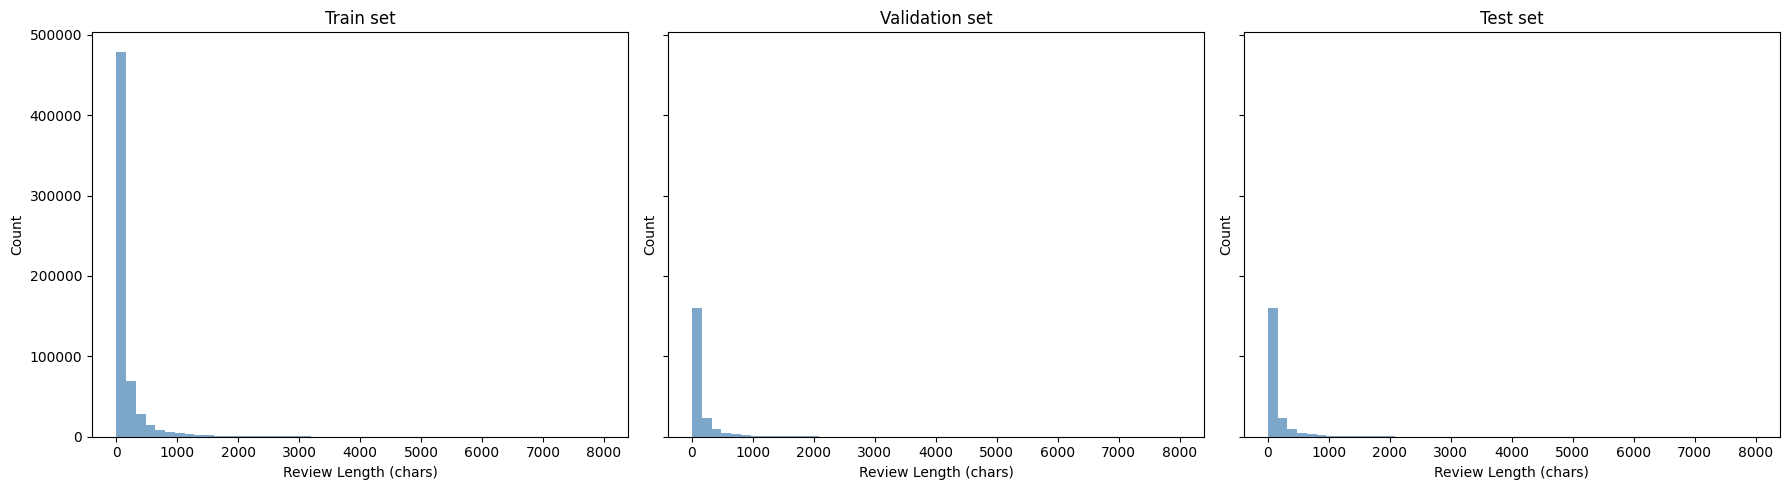

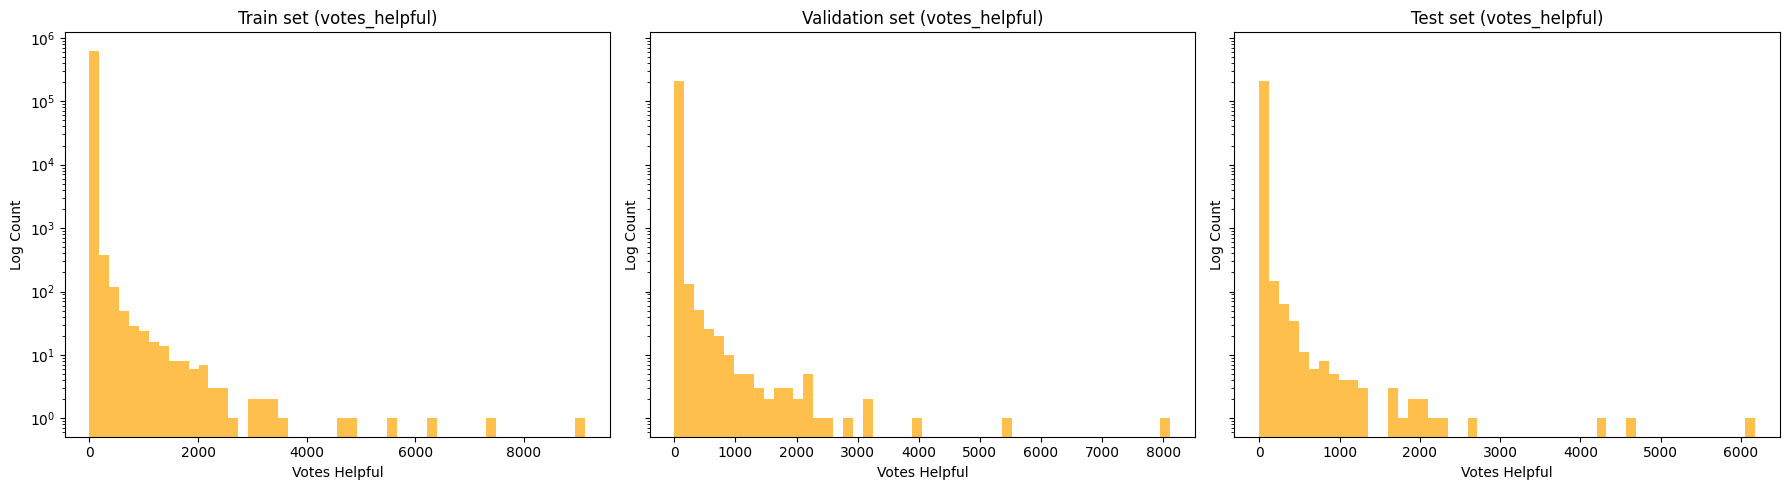

In [9]:
import matplotlib.pyplot as plt

# Plot histograms of review_length_chars for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, split_df, label in zip(
    axes,
    [train_df, val_df, test_df],
    ["Train", "Validation", "Test"]
):
    ax.hist(split_df["review_length_chars"], bins=50, color="steelblue", alpha=0.7)
    ax.set_title(f"{label} set")
    ax.set_xlabel("Review Length (chars)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Plot histograms of votes_helpful for each dataset (log scale for readability)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, split_df, label in zip(
    axes,
    [train_df, val_df, test_df],
    ["Train", "Validation", "Test"]
):
    ax.hist(split_df["votes_helpful"], bins=50, color="orange", alpha=0.7, log=True)
    ax.set_title(f"{label} set (votes_helpful)")
    ax.set_xlabel("Votes Helpful")
    ax.set_ylabel("Log Count")

plt.tight_layout()
plt.show()